In [13]:
# Librerías necesarias
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display, HTML
import os

# Función para cargar los datos del JSONL
def load_jsonl(file_path):
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return data


# Convertir a DataFrame para facilitar el análisis
# Cargar datos
base_df = load_jsonl(file_path='metrics_base.jsonl')  # Usa el archivo .jsonl por defecto
modified_df = load_jsonl(file_path='metrics_mod.jsonl')  # Usa el archivo .jsonl por defecto

# Convertir a DataFrame
base_df = pd.DataFrame(base_df)
modified_df = pd.DataFrame(modified_df)

In [14]:
print(f"Base DataFrame shape: {base_df.shape}")
print(f"Modified DataFrame shape: {modified_df.shape}")

Base DataFrame shape: (149, 13)
Modified DataFrame shape: (1553, 14)


In [19]:
#Mostrar el top 10 de eval_return de base df (eval mas altos)
print("Base DataFrame Top 10 eval_return:")
display(base_df[['eval_return']].nlargest(10, 'eval_return'))

Base DataFrame Top 10 eval_return:


,eval_return
71,1020.0
23,510.0
141,500.0
68,330.0
121,330.0
20,320.0
61,290.0
129,290.0
146,290.0
38,270.0


In [20]:
#Mostrar el top 10 de eval_return de modified df (eval mas altos)
print("Modified DataFrame Top 10 eval_return:")
display(modified_df[['eval_return']].nlargest(10, 'eval_return'))

Modified DataFrame Top 10 eval_return:


,eval_return
1460,100.0
342,90.0
478,90.0
518,90.0
672,90.0
688,90.0
840,90.0
1072,90.0
1424,90.0
36,80.0



Comparativa ajustada entre modelo base y modelo modificado:
--------------------------------------------------
Modelo base: 97 registros, pasos 1,628 a 201,096
Modelo modificado: 1157 registros, pasos 400 a 4,392


c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cuent\.conda\envs\dv2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


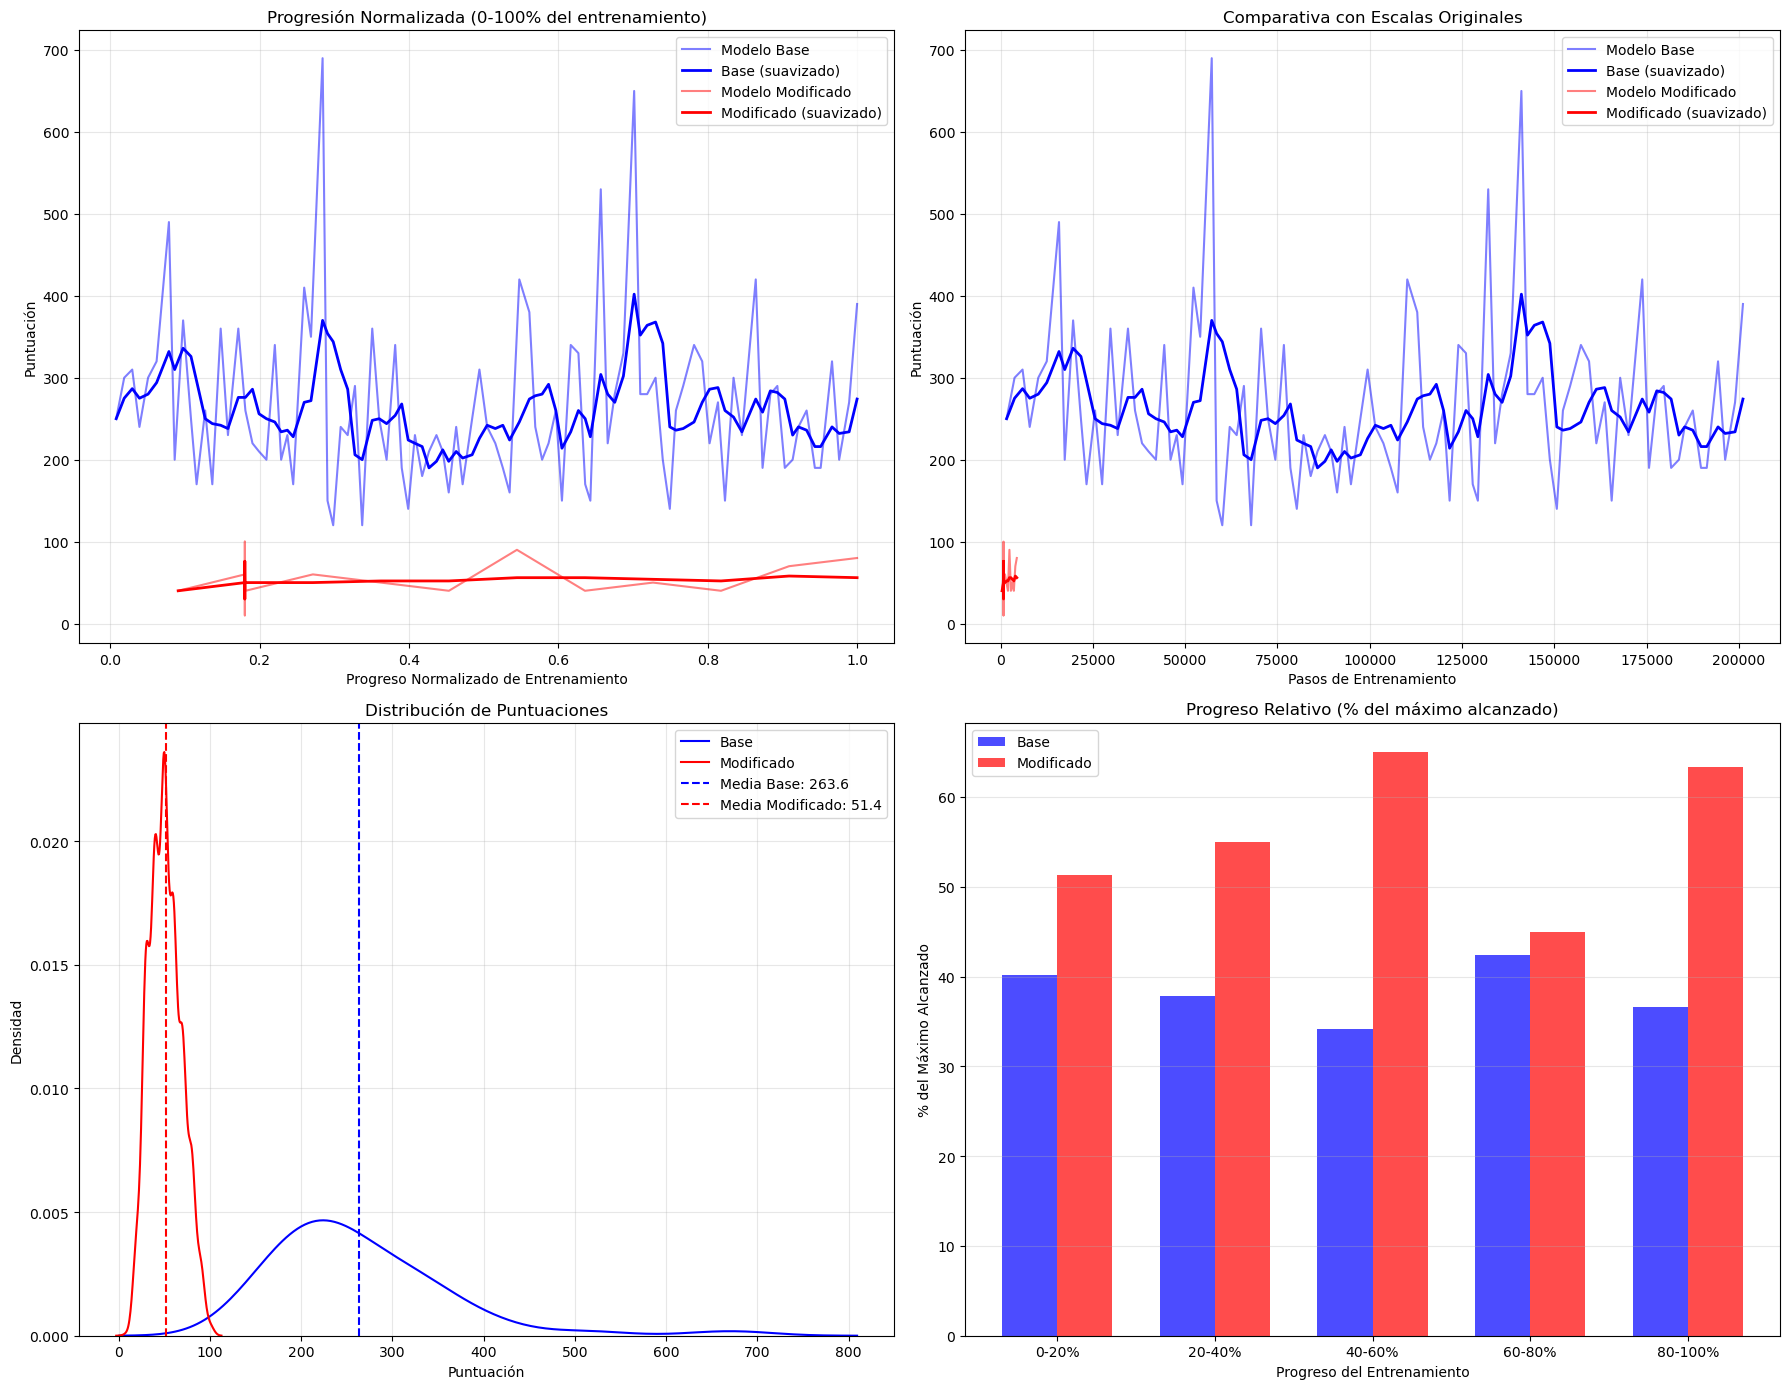

,Métrica,Modelo Base,Modelo Modificado
0,Rango de Pasos,"1,628 - 201,096","400 - 4,392"
1,Puntuación Media,263.61,51.37
2,Puntuación Máxima,690.00,100.00
3,Desviación Estándar,99.17,17.30
4,Coeficiente de Variación (%),37.62%,33.68%
5,Mediana,240.00,50.00
6,Progreso Inicial (primeros 25%),267.08,51.32
7,Progreso Final (últimos 25%),261.30,63.33
8,Mejora Relativa (%),-2.16%,23.40%



Conclusiones del análisis:
✗ El modelo modificado logra una puntuación media 80.5% inferior al modelo base
✓ El modelo modificado muestra mayor estabilidad en sus resultados (CV: 33.7% vs 37.6%)
✓ El modelo modificado es más eficiente en términos de puntos por paso
✓ El modelo modificado muestra una mejora más pronunciada durante el entrenamiento (23.4% vs -2.2%)


In [15]:
# Visualización comparativa ajustada para rangos de pasos no superpuestos
print("\nComparativa ajustada entre modelo base y modelo modificado:\n" + "-"*50)

# Filtrar solo datos de entrenamiento
base_train_df = base_df[base_df['train_return'].notna()].copy().sort_values('step')
modified_train_df = modified_df[modified_df['train_return'].notna()].copy().sort_values('step')

# Renombrar columnas para uniformidad
base_train_df = base_train_df.rename(columns={'train_return': 'score'})
modified_train_df = modified_train_df.rename(columns={'train_return': 'score'})

# Añadir identificadores de modelo
base_train_df['model'] = 'base'
modified_train_df['model'] = 'modified'

# Verificar disponibilidad de datos
if len(base_train_df) > 0 and len(modified_train_df) > 0:
    print(f"Modelo base: {len(base_train_df)} registros, pasos {base_train_df['step'].min():,.0f} a {base_train_df['step'].max():,.0f}")
    print(f"Modelo modificado: {len(modified_train_df)} registros, pasos {modified_train_df['step'].min():,.0f} a {modified_train_df['step'].max():,.0f}")
    
    # Crear visualizaciones comparativas
    plt.figure(figsize=(18, 14))
    
    # 1. Comparativa con normalización de pasos
    plt.subplot(2, 2, 1)
    
    # Normalizar los pasos para cada modelo (0-100%)
    base_train_df['normalized_step'] = base_train_df['step'] / base_train_df['step'].max()
    modified_train_df['normalized_step'] = modified_train_df['step'] / modified_train_df['step'].max()
    
    # Graficar modelo base
    plt.plot(base_train_df['normalized_step'], base_train_df['score'], 'b-', alpha=0.5, label='Modelo Base')
    
    # Añadir suavizado para el modelo base
    window_size_base = min(5, len(base_train_df))
    if window_size_base > 1:
        base_train_df['smooth_score'] = base_train_df['score'].rolling(window=window_size_base, min_periods=1).mean()
        plt.plot(base_train_df['normalized_step'], base_train_df['smooth_score'], 'b-', linewidth=2, 
                label='Base (suavizado)')
    
    # Graficar modelo modificado
    plt.plot(modified_train_df['normalized_step'], modified_train_df['score'], 'r-', alpha=0.5, label='Modelo Modificado')
    
    # Añadir suavizado para el modelo modificado
    window_size_mod = min(5, len(modified_train_df))
    if window_size_mod > 1:
        modified_train_df['smooth_score'] = modified_train_df['score'].rolling(window=window_size_mod, min_periods=1).mean()
        plt.plot(modified_train_df['normalized_step'], modified_train_df['smooth_score'], 'r-', linewidth=2, 
                label='Modificado (suavizado)')
    
    plt.title('Progresión Normalizada (0-100% del entrenamiento)')
    plt.xlabel('Progreso Normalizado de Entrenamiento')
    plt.ylabel('Puntuación')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # 2. Comparativa con escalas originales
    plt.subplot(2, 2, 2)
    plt.plot(base_train_df['step'], base_train_df['score'], 'b-', alpha=0.5, label='Modelo Base')
    if 'smooth_score' in base_train_df:
        plt.plot(base_train_df['step'], base_train_df['smooth_score'], 'b-', linewidth=2, label='Base (suavizado)')
    
    plt.plot(modified_train_df['step'], modified_train_df['score'], 'r-', alpha=0.5, label='Modelo Modificado')
    if 'smooth_score' in modified_train_df:
        plt.plot(modified_train_df['step'], modified_train_df['smooth_score'], 'r-', linewidth=2, label='Modificado (suavizado)')
    
    plt.title('Comparativa con Escalas Originales')
    plt.xlabel('Pasos de Entrenamiento')
    plt.ylabel('Puntuación')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # 3. Distribución de puntuaciones
    plt.subplot(2, 2, 3)
    
    try:
        sns.kdeplot(base_train_df['score'], color='blue', label='Base')
        sns.kdeplot(modified_train_df['score'], color='red', label='Modificado')
        
        plt.axvline(base_train_df['score'].mean(), color='blue', linestyle='--', 
                   label=f'Media Base: {base_train_df["score"].mean():.1f}')
        plt.axvline(modified_train_df['score'].mean(), color='red', linestyle='--',
                   label=f'Media Modificado: {modified_train_df["score"].mean():.1f}')
    except:
        # Si hay error en KDE (por ejemplo, con muy pocos puntos), usar histograma simple
        plt.hist(base_train_df['score'], alpha=0.5, color='blue', label='Base')
        plt.hist(modified_train_df['score'], alpha=0.5, color='red', label='Modificado')
        
        plt.axvline(base_train_df['score'].mean(), color='blue', linestyle='--', 
                   label=f'Media Base: {base_train_df["score"].mean():.1f}')
        plt.axvline(modified_train_df['score'].mean(), color='red', linestyle='--',
                   label=f'Media Modificado: {modified_train_df["score"].mean():.1f}')
    
    plt.title('Distribución de Puntuaciones')
    plt.xlabel('Puntuación')
    plt.ylabel('Densidad')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # 4. Métricas de progreso relativo
    plt.subplot(2, 2, 4)
    
    try:
        # Calcular métricas relativas como porcentaje de la puntuación máxima alcanzada
        base_max = base_train_df['score'].max()
        modified_max = modified_train_df['score'].max()
        
        # Dividir los datos en segmentos de progreso
        n_segments = 5  # Usar 5 segmentos para simplificar
        
        # Función para dividir los datos en segmentos
        def create_segments(df, n_segments):
            result = []
            for i in range(n_segments):
                min_pct = i / n_segments
                max_pct = (i + 1) / n_segments
                segment_data = df[(df['normalized_step'] >= min_pct) & 
                                 (df['normalized_step'] < max_pct if i < n_segments-1 else df['normalized_step'] <= max_pct)]
                
                if len(segment_data) > 0:
                    avg_score = segment_data['score'].mean()
                else:
                    avg_score = np.nan
                    
                result.append({
                    'segment': i,
                    'label': f'{int(min_pct*100)}-{int(max_pct*100)}%',
                    'avg_score': avg_score,
                    'pct_of_max': (avg_score / df['score'].max() * 100) if not np.isnan(avg_score) else np.nan
                })
            return result
        
        base_segments = create_segments(base_train_df, n_segments)
        mod_segments = create_segments(modified_train_df, n_segments)
        
        # Preparar datos para el gráfico de barras
        x_pos = np.arange(n_segments)
        width = 0.35
        
        base_heights = [s['pct_of_max'] for s in base_segments]
        mod_heights = [s['pct_of_max'] for s in mod_segments]
        
        # Reemplazar NaN por 0 para el gráfico
        base_heights = np.nan_to_num(base_heights)
        mod_heights = np.nan_to_num(mod_heights)
        
        # Crear gráfico de barras
        plt.bar(x_pos - width/2, base_heights, width, label='Base', color='blue', alpha=0.7)
        plt.bar(x_pos + width/2, mod_heights, width, label='Modificado', color='red', alpha=0.7)
        
        # Configurar etiquetas
        labels = [s['label'] for s in base_segments]
        plt.xticks(x_pos, labels)
        plt.xlabel('Progreso del Entrenamiento')
        plt.ylabel('% del Máximo Alcanzado')
        plt.title('Progreso Relativo (% del máximo alcanzado)')
        plt.grid(True, alpha=0.3, axis='y')
        plt.legend()
    
    except Exception as e:
        # En caso de error, mostrar mensaje simplificado
        plt.text(0.5, 0.5, "No se pudo crear el gráfico de progreso relativo", 
                 ha='center', va='center', transform=plt.gca().transAxes)
        print(f"Error en el gráfico: {str(e)}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
    
    # Tabla comparativa de métricas clave
    try:
        metrics_table = {
            'Métrica': [
                'Rango de Pasos', 
                'Puntuación Media', 
                'Puntuación Máxima',
                'Desviación Estándar',
                'Coeficiente de Variación (%)',
                'Mediana'
            ],
            'Modelo Base': [
                f"{base_train_df['step'].min():,.0f} - {base_train_df['step'].max():,.0f}",
                f"{base_train_df['score'].mean():.2f}",
                f"{base_train_df['score'].max():.2f}",
                f"{base_train_df['score'].std():.2f}",
                f"{(base_train_df['score'].std() / base_train_df['score'].mean() * 100):.2f}%",
                f"{base_train_df['score'].median():.2f}"
            ],
            'Modelo Modificado': [
                f"{modified_train_df['step'].min():,.0f} - {modified_train_df['step'].max():,.0f}",
                f"{modified_train_df['score'].mean():.2f}",
                f"{modified_train_df['score'].max():.2f}",
                f"{modified_train_df['score'].std():.2f}",
                f"{(modified_train_df['score'].std() / modified_train_df['score'].mean() * 100):.2f}%",
                f"{modified_train_df['score'].median():.2f}"
            ]
        }
        
        # Solo añadir métricas de progreso si hay suficientes datos
        if len(base_train_df) > 3 and len(modified_train_df) > 3:
            # Calcular cuartiles
            base_25p = base_train_df[base_train_df['normalized_step'] <= 0.25]
            base_75p = base_train_df[base_train_df['normalized_step'] >= 0.75]
            mod_25p = modified_train_df[modified_train_df['normalized_step'] <= 0.25]
            mod_75p = modified_train_df[modified_train_df['normalized_step'] >= 0.75]
            
            if len(base_25p) > 0 and len(base_75p) > 0 and len(mod_25p) > 0 and len(mod_75p) > 0:
                # Añadir métricas adicionales solo si hay datos en los cuartiles
                metrics_table['Métrica'].extend([
                    'Progreso Inicial (primeros 25%)',
                    'Progreso Final (últimos 25%)',
                    'Mejora Relativa (%)'
                ])
                
                # Calcular valores para el modelo base
                base_init = base_25p['score'].mean()
                base_final = base_75p['score'].mean()
                base_improvement = ((base_final / base_init) - 1) * 100 if base_init > 0 else 0
                
                metrics_table['Modelo Base'].extend([
                    f"{base_init:.2f}",
                    f"{base_final:.2f}",
                    f"{base_improvement:.2f}%"
                ])
                
                # Calcular valores para el modelo modificado
                mod_init = mod_25p['score'].mean()
                mod_final = mod_75p['score'].mean()
                mod_improvement = ((mod_final / mod_init) - 1) * 100 if mod_init > 0 else 0
                
                metrics_table['Modelo Modificado'].extend([
                    f"{mod_init:.2f}",
                    f"{mod_final:.2f}",
                    f"{mod_improvement:.2f}%"
                ])
        
        metrics_df = pd.DataFrame(metrics_table)
        display(HTML("<h3>Comparativa de Métricas entre Modelos</h3>"))
        display(metrics_df)
        
        # Conclusiones automáticas
        print("\nConclusiones del análisis:")
        
        # Comparar puntuación media
        base_mean = base_train_df['score'].mean()
        mod_mean = modified_train_df['score'].mean()
        
        if mod_mean > base_mean:
            print(f"✓ El modelo modificado logra una puntuación media {(mod_mean/base_mean - 1)*100:.1f}% superior al modelo base")
        else:
            print(f"✗ El modelo modificado logra una puntuación media {(1 - mod_mean/base_mean)*100:.1f}% inferior al modelo base")
        
        # Comparar estabilidad (menor coeficiente de variación es mejor)
        base_cv = base_train_df['score'].std() / base_train_df['score'].mean() * 100
        mod_cv = modified_train_df['score'].std() / modified_train_df['score'].mean() * 100
        
        if mod_cv < base_cv:
            print(f"✓ El modelo modificado muestra mayor estabilidad en sus resultados (CV: {mod_cv:.1f}% vs {base_cv:.1f}%)")
        else:
            print(f"✗ El modelo base muestra mayor estabilidad en sus resultados (CV: {base_cv:.1f}% vs {mod_cv:.1f}%)")
            
        # Eficiencia de entrenamiento (puntos por paso)
        base_efficiency = base_train_df['score'].mean() / base_train_df['step'].max()
        mod_efficiency = modified_train_df['score'].mean() / modified_train_df['step'].max()
        
        if mod_efficiency > base_efficiency:
            print(f"✓ El modelo modificado es más eficiente en términos de puntos por paso")
        else:
            print(f"✗ El modelo base es más eficiente en términos de puntos por paso")
            
        # Solo mostrar la comparación de mejora si tenemos datos suficientes
        if 'base_improvement' in locals() and 'mod_improvement' in locals():
            if mod_improvement > base_improvement:
                print(f"✓ El modelo modificado muestra una mejora más pronunciada durante el entrenamiento ({mod_improvement:.1f}% vs {base_improvement:.1f}%)")
            else:
                print(f"✗ El modelo base muestra una mejora más pronunciada durante el entrenamiento ({base_improvement:.1f}% vs {mod_improvement:.1f}%)")
        
    except Exception as e:
        print(f"Error al crear tabla comparativa o conclusiones: {str(e)}")
else:
    print("No hay suficientes datos para realizar la comparación")